<a href="https://colab.research.google.com/github/Oliwia501/customer-churn-prediction-and-retention-strategy/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI for Communication and Marketing
# Customer Churn Prediction

---

**Dataset:** E-commerce customer profiles, satisfaction scores, and transaction summaries  
**Goal:** Build a predictive model to identify customers at risk of churning and provide actionable marketing insights

---

## Setup & Library Imports

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)

#plots style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (8, 4)

---
#A — Data Audit & Quality
## Dataset Overview

In [2]:
file_path = "https://raw.githubusercontent.com/Oliwia501/customer-churn-prediction-and-retention-strategy/main/data/data.xlsx"

df = pd.read_excel(file_path, sheet_name="E Comm")

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 5630 rows × 20 columns


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001.0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002.0,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003.0,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004.0,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005.0,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
#dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5628 non-null   float64
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5628 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [4]:
# Basic statistics for numerical columns
df.describe().round(2)

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5628.00,5630.00,5366.00,5630.00,5379.00,5375.00,5630.00,5630.00,5630.00,5630.00,5365.00,5374.00,5372.00,5323.00,5630.00
mean,52814.55,0.17,10.19,1.65,15.64,2.93,3.69,3.07,4.21,0.28,15.71,1.75,3.01,4.54,532.40
std,1624.89,0.37,8.56,0.92,8.53,0.72,1.02,1.38,2.58,0.45,3.68,1.89,2.94,3.65,18842.84
min,50001.00,0.00,0.00,1.00,5.00,0.00,1.00,1.00,1.00,0.00,11.00,0.00,1.00,0.00,0.00
25%,51407.75,0.00,2.00,1.00,9.00,2.00,3.00,2.00,2.00,0.00,13.00,1.00,1.00,2.00,145.77
50%,52814.50,0.00,9.00,1.00,14.00,3.00,4.00,3.00,3.00,0.00,15.00,1.00,2.00,3.00,163.33
75%,54221.25,0.00,16.00,3.00,20.00,3.00,4.00,4.00,6.00,1.00,18.00,2.00,3.00,7.00,196.42
max,55630.00,1.00,61.00,3.00,127.00,5.00,6.00,5.00,22.00,1.00,26.00,16.00,16.00,46.00,999999.00


In [5]:
# Check for duplicates
n_dup = df.duplicated().sum()
print(f"Number of duplicate rows: {n_dup}")

Number of duplicate rows: 0


## Missing Values Analysis


In [6]:
# Count and percentage of missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

                             Missing Count  Missing %
DaySinceLastOrder                      307       5.45
OrderAmountHikeFromlastYear            265       4.71
Tenure                                 264       4.69
OrderCount                             258       4.58
CouponUsed                             256       4.55
HourSpendOnApp                         255       4.53
WarehouseToHome                        251       4.46
CustomerID                               2       0.04
Gender                                   2       0.04


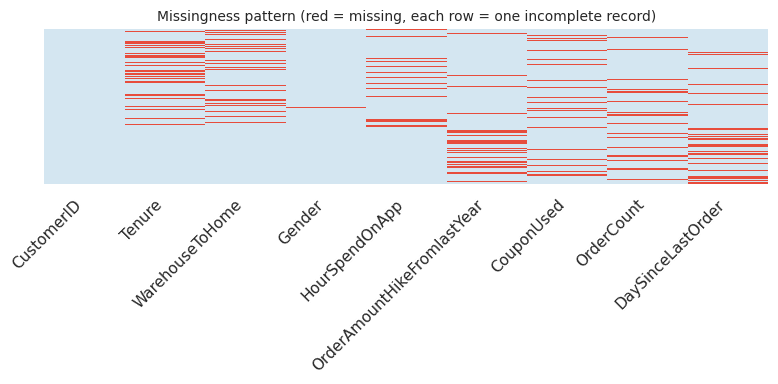

In [7]:
# Missingness pattern heatmap
missing_cols = [col for col in df.columns if df[col].isnull().any()]
rows_with_missing = df[df[missing_cols].isnull().any(axis=1)][missing_cols]

miss_matrix = rows_with_missing.isnull().astype(int)
sns.heatmap(
    miss_matrix,
    cmap=['#d4e6f1', '#e74c3c'],
    cbar=False,
    xticklabels=True,
    yticklabels=False,
    linewidths=0.0
)
plt.title('Missingness pattern (red = missing, each row = one incomplete record)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Imputation Strategy:**

Most columns have a relatively small percentage of missing data (under 10%). I decided to use **median imputation** for numerical columns because many of them are skewed
(e.g., `Tenure`, `WarehouseToHome`, `DaySinceLastOrder`). The median is more robust to outliers than the mean.
For `HourSpendOnApp` and `OrderAmountHikeFromlastYear,` median also makes sense.

I'm not dropping those rows because the missing data seems to be mostly random (MAR), not systematic and the dataset is not huge.


Only ows with missing `CustomerID` or `Gender` were dropped because these are key identification or demographic variables and only 4 rows were affected.

In [8]:
# Impute numerical columns with median
num_cols_with_missing = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                          'OrderAmountHikeFromlastYear', 'CouponUsed',
                          'OrderCount', 'DaySinceLastOrder']

for col in num_cols_with_missing:
    if col in df.columns and df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Imputed '{col}' with median = {median_val:.2f}")

# Drop the 2 rows missing CustomerID and the 2 rows missing
before = len(df)
df.dropna(subset=['CustomerID', 'Gender'], inplace=True)
print(f"Rows dropped: {before - len(df)}")
print(f"Remaining rows: {len(df)}")
print(f"Any missing values left: {df.isnull().sum().sum()}")


Imputed 'Tenure' with median = 9.00
Imputed 'WarehouseToHome' with median = 14.00
Imputed 'HourSpendOnApp' with median = 3.00
Imputed 'OrderAmountHikeFromlastYear' with median = 15.00
Imputed 'CouponUsed' with median = 1.00
Imputed 'OrderCount' with median = 2.00
Imputed 'DaySinceLastOrder' with median = 3.00
Rows dropped: 4
Remaining rows: 5626
Any missing values left: 0


## Data Consistency Checks

In [9]:
# Check ranges for suspicious columns
print("=== WarehouseToHome range ===")
print(df['WarehouseToHome'].describe())

print("\n=== Tenure range ===")
print(df['Tenure'].describe())

print("\n=== DaySinceLastOrder range ===")
print(df['DaySinceLastOrder'].describe())

print("\n=== CashbackAmount range ===")
print(df['CashbackAmount'].describe())

=== WarehouseToHome range ===
count    5626.000000
mean       15.563100
std         8.344048
min         5.000000
25%         9.000000
50%        14.000000
75%        20.000000
max       127.000000
Name: WarehouseToHome, dtype: float64

=== Tenure range ===
count    5626.000000
mean       10.137931
std         8.358702
min         0.000000
25%         3.000000
50%         9.000000
75%        15.000000
max        61.000000
Name: Tenure, dtype: float64

=== DaySinceLastOrder range ===
count    5626.000000
mean        4.459474
std         3.571075
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        46.000000
Name: DaySinceLastOrder, dtype: float64

=== CashbackAmount range ===
count      5626.000000
mean        532.664083
std       18849.532943
min           0.000000
25%         145.770000
50%         163.330000
75%         196.430000
max      999999.000000
Name: CashbackAmount, dtype: float64


In [10]:
# WarehouseToHome: values above 100 km seem unrealistic for local delivery
suspicious_wth = df[df['WarehouseToHome'] > 100]
print(f"WarehouseToHome > 100: {len(suspicious_wth)} rows")
print(suspicious_wth[['CustomerID', 'WarehouseToHome']].head(10))

WarehouseToHome > 100: 2 rows
      CustomerID  WarehouseToHome
1309     51310.0            126.0
4124     54125.0            127.0


In [11]:
# Tenure: negative values would be impossible
negative_tenure = df[df['Tenure'] < 0]
print(f"Tenure < 0: {len(negative_tenure)} rows")

# Check unique values in categorical columns
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
            'PreferedOrderCat', 'MaritalStatus']
for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")

Tenure < 0: 0 rows

PreferredLoginDevice: ['Mobile Phone' 'Phone' 'Computer' 'N.A.']

PreferredPaymentMode: ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender: ['Female' 'Male']

PreferedOrderCat: ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

MaritalStatus: ['Single' 'Divorced' 'Married' 'Widow']


**What was found:**

- `WarehouseToHome` has some very high values but they could represent real customers in far-out areas.
- `Tenure` no negatives and the range makes sense for an e-commerce platform.
- Some categorical columns have inconsistencies (e.g., `CC` and `Credit Card` probably mean the same thing, same with `COD` and `Cash on Delivery`). I'll standardize these.
- `PreferredLoginDevice` also has `Phone` and `Mobile Phone` which could be the same.

In [12]:
# Standardize categorical inconsistencies

# Payment mode: CC → Credit Card, COD → Cash on Delivery
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery'
})

# Login device: Phone → Mobile Phone (treating them the same)
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({
    'Phone': 'Mobile Phone'
})

print("Payment modes after cleaning:")
print(df['PreferredPaymentMode'].value_counts())

print("\nLogin devices after cleaning:")
print(df['PreferredLoginDevice'].value_counts())

Payment modes after cleaning:
PreferredPaymentMode
Debit Card          2313
Credit Card         1772
E wallet             613
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

Login devices after cleaning:
PreferredLoginDevice
Mobile Phone    3991
Computer        1630
N.A.               5
Name: count, dtype: int64


## Outlier Analysis


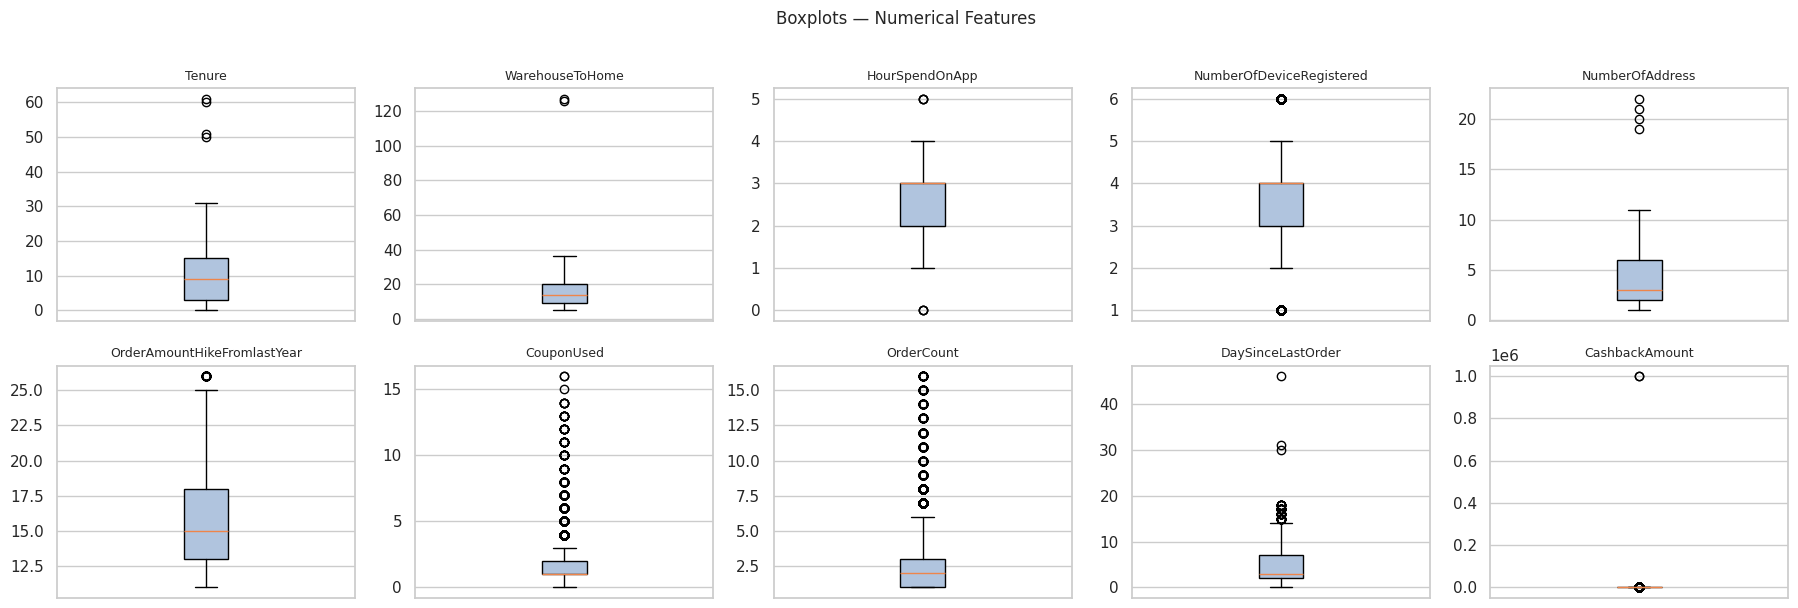

In [13]:
# Boxplots for key numeric columns
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
            'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])

plt.suptitle('Boxplots — Numerical Features', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# IQR-based outlier detection
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

print(f"{'Column':<35} {'Outliers':>10} {'Lower Bound':>15} {'Upper Bound':>15}")
print('-' * 80)
for col in num_cols:
    n_out, lo, hi = count_outliers_iqr(df[col].dropna())
    print(f"{col:<35} {n_out:>10} {lo:>15.2f} {hi:>15.2f}")

Column                                Outliers     Lower Bound     Upper Bound
--------------------------------------------------------------------------------
Tenure                                       4          -15.00           33.00
WarehouseToHome                              2           -7.50           36.50
HourSpendOnApp                               6            0.50            4.50
NumberOfDeviceRegistered                   397            1.50            5.50
NumberOfAddress                              4           -4.00           12.00
OrderAmountHikeFromlastYear                 33            5.50           25.50
CouponUsed                                 629           -0.50            3.50
OrderCount                                 703           -2.00            6.00
DaySinceLastOrder                           62           -5.50           14.50
CashbackAmount                             440           69.78          272.42


**Outlier Decision:**

Looking at the boxplots and IQR output:
- `WarehouseToHome` has some extreme values (e.g. customers living very far). These could be real,
  so I'll cap at the 99th percentile rather than remove them
- `CouponUsed`, `OrderCount`, and `NumberOfAddress` have high-end outliers that likely represent power users, `i'll keep these as they are interesting from a marketing perspective.
- `CashbackAmount` shows a right tail but the values aren't unrealistic

In [15]:
# Cap WarehouseToHome at 99th percentile
cap_wth = df['WarehouseToHome'].quantile(0.99)
df['WarehouseToHome'] = df['WarehouseToHome'].clip(upper=cap_wth)
print(f"WarehouseToHome capped at {cap_wth:.1f} km (99th percentile)")
print(f"New max: {df['WarehouseToHome'].max()}")

WarehouseToHome capped at 35.0 km (99th percentile)
New max: 35.0


## Encoding Categorical Variables

**Strategy:**
- **Label Encoding** for binary or ordinal columns
- **One-Hot Encoding** for nominal columns with more than 2 categories

In [16]:
# Store a copy of the original for reference
df_original = df.copy()

# Label encode binary / low-cardinality columns
le = LabelEncoder()
label_encode_cols = ['PreferredLoginDevice', 'Gender', 'MaritalStatus', 'PreferedOrderCat']

for col in label_encode_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Label encoded: {col}")

# One-hot encode payment mode (multiple categories)
df = pd.get_dummies(df, columns=['PreferredPaymentMode'], drop_first=True, dtype=int)

# Drop CustomerID — not useful for modeling
df.drop(columns=['CustomerID'], inplace=True)

print(f"\nDataset shape after encoding: {df.shape}")
print("\nFeature list:")
print(df.columns.tolist())

Label encoded: PreferredLoginDevice
Label encoded: Gender
Label encoded: MaritalStatus
Label encoded: PreferedOrderCat

Dataset shape after encoding: (5626, 22)

Feature list:
['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI']


### summary
- The dataset had missing values in about 8 columns, mostly numerical. All were imputed with the median.
- I found some categorical inconsistencies (e.g., `CC` vs `Credit Card`) and standardized them.
- Outliers are present in `WarehouseToHome` and we capped them; for other columns I chose to keep extreme values.


---
#B — Exploratory Data Analysis (EDA)
## Churn Distribution

How balanced is target variable?

Churn distribution:
       Count  Percentage
Churn                   
0       4679       83.17
1        947       16.83


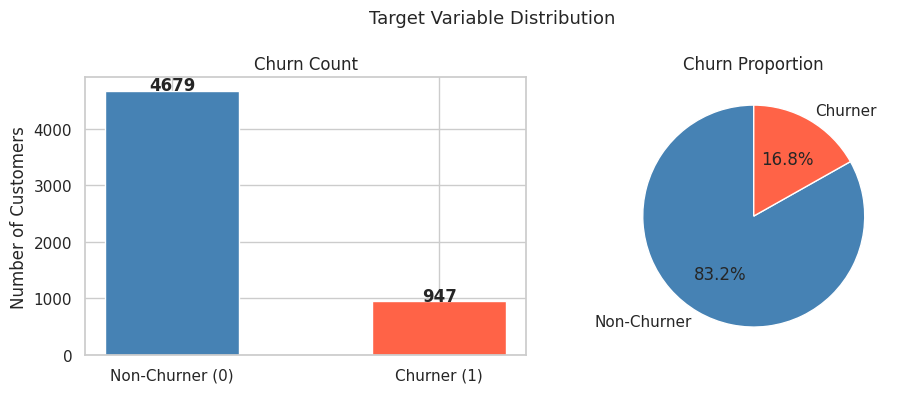

In [17]:
# Churn counts and percentages
churn_counts = df_original['Churn'].value_counts()
churn_pct = df_original['Churn'].value_counts(normalize=True) * 100

print("Churn distribution:")
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
axes[0].bar(['Non-Churner (0)', 'Churner (1)'], churn_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Non-Churner', 'Churner'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable Distribution', fontsize=13)
plt.tight_layout()
plt.show()

**Class Balance:**

The dataset is **skewed towards non-churners** roughly 83% of customers did not churn and about 17% did.


## Satisfaction Score and Churn

How customer satisfaction relates to churn.

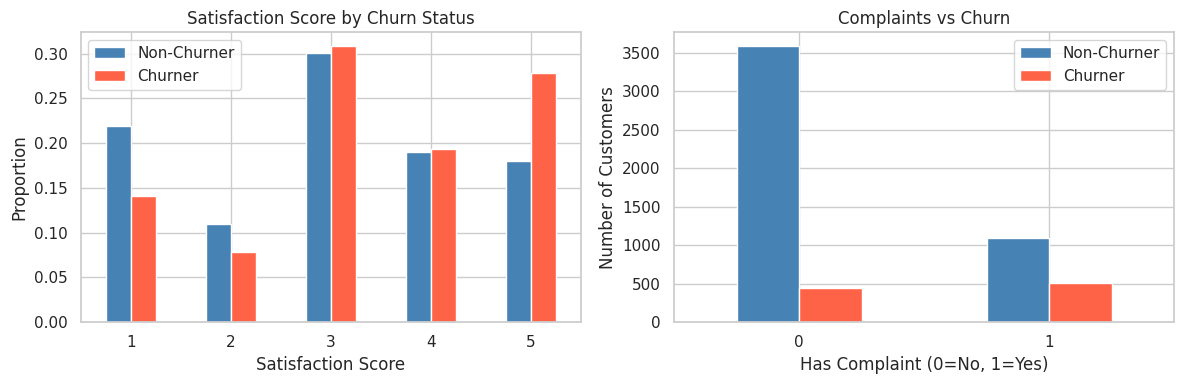

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Satisfaction score distribution by churn
df_original.groupby('Churn')['SatisfactionScore'].value_counts(normalize=True).unstack().T.plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_title('Satisfaction Score by Churn Status')
axes[0].set_xlabel('Satisfaction Score')
axes[0].set_ylabel('Proportion')
axes[0].legend(['Non-Churner', 'Churner'])
axes[0].tick_params(axis='x', rotation=0)

# Complain vs Churn
complain_churn = df_original.groupby(['Complain', 'Churn']).size().unstack()
complain_churn.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'],
                    edgecolor='white', width=0.5)
axes[1].set_title('Complaints vs Churn')
axes[1].set_xlabel('Has Complaint (0=No, 1=Yes)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(['Non-Churner', 'Churner'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [19]:
# Average satisfaction by churn
print("Average Satisfaction Score:")
print(df_original.groupby('Churn')['SatisfactionScore'].mean().round(3))

print("\nChurn rate by Complain:")
print(df_original.groupby('Complain')['Churn'].mean().round(3))

Average Satisfaction Score:
Churn
0    3.002
1    3.390
Name: SatisfactionScore, dtype: float64

Churn rate by Complain:
Complain
0    0.109
1    0.317
Name: Churn, dtype: float64


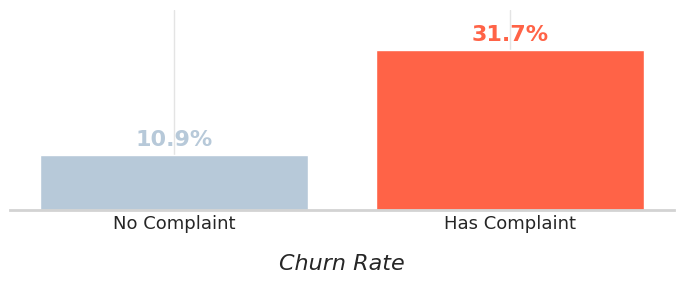

In [20]:
complain_churn = (
    df_original.groupby('Complain')['Churn']
    .mean()
    .mul(100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(7, 3))

colors = ['#b7c9d9', 'tomato']

bars = ax.bar(
    ['No Complaint', 'Has Complaint'],
    complain_churn.values,
    color=colors,
    width=0.8
)

# percentages above bars
for bar, value in zip(bars, complain_churn.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=16,
        fontweight='bold',
        color=bar.get_facecolor()
    )

# clean business style
ax.set_ylim(0, max(complain_churn.values) * 1.25)

ax.set_ylabel('')
ax.set_yticks([])

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.spines['bottom'].set_color('lightgray')
ax.spines['bottom'].set_linewidth(2)

ax.grid(axis='x', color='lightgray', linewidth=1, alpha=0.6)

ax.tick_params(axis='x', length=0, labelsize=13)

ax.set_xlabel(
    'Churn Rate',
    fontsize=16,
    fontstyle='italic',
    labelpad=15
)

plt.tight_layout()
plt.show()

**Interpretation:**

- Interestingly, **satisfaction score alone doesn't show a strong linear relationship** with churn.
  Churners seem spread across all satisfaction levels, not just the dissatisfied ones.

- **Complaints:** Much clearer signal. Customers who complained have a 31.7% churn rate vs only 10.9% for those who didn't. An unresolved complaint is a far stronger churn trigger than low satisfaction

## Tenure and Churn

How does customer tenure (length of relationship with the platform) relate to churn?

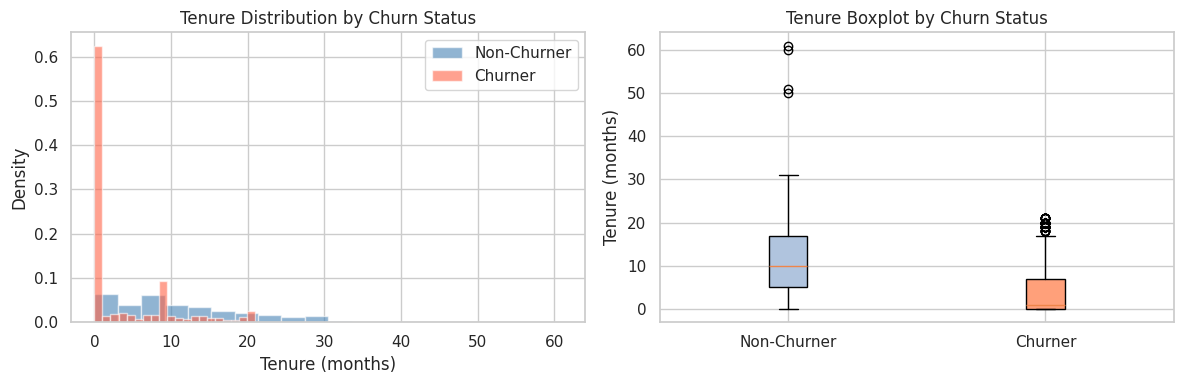

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# KDE / distribution of tenure by churn
for churn_val, label, color in [(0, 'Non-Churner', 'steelblue'), (1, 'Churner', 'tomato')]:
    subset = df_original[df_original['Churn'] == churn_val]['Tenure'].dropna()
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white', density=True)
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot
data_to_plot = [df_original[df_original['Churn']==0]['Tenure'].dropna(),
                df_original[df_original['Churn']==1]['Tenure'].dropna()]
bp = axes[1].boxplot(data_to_plot, labels=['Non-Churner', 'Churner'], patch_artist=True,
                     boxprops=dict(facecolor='lightsteelblue'))
bp['boxes'][1].set_facecolor('lightsalmon')
axes[1].set_title('Tenure Boxplot by Churn Status')
axes[1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.show()

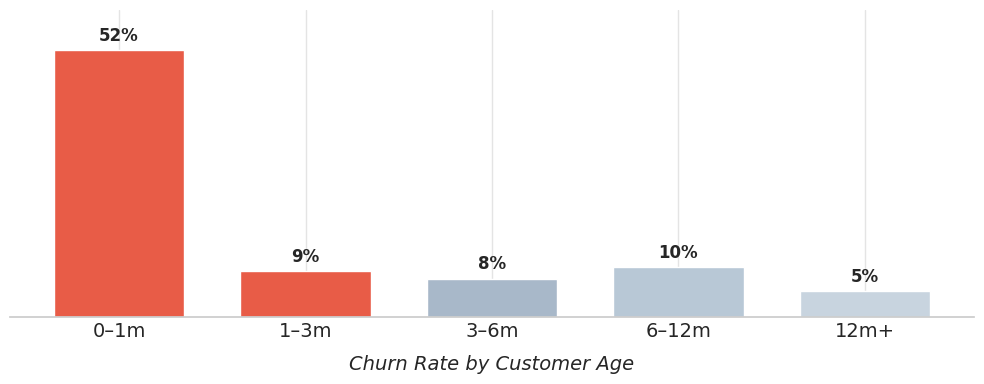

In [22]:
df_original['Tenure_Group'] = pd.cut(
    df_original['Tenure'],
    bins=[0, 1, 3, 6, 12, df_original['Tenure'].max()],
    labels=['0–1m', '1–3m', '3–6m', '6–12m', '12m+'],
    include_lowest=True
)
# Calculate churn rate per group
churn_by_tenure = (
    df_original
    .groupby('Tenure_Group')['Churn']
    .mean()
    .mul(100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(10, 4))

colors = ['#e85c47', '#e85c47','#a8b8c9','#b8c8d6', '#c8d4df']

bars = ax.bar(
    churn_by_tenure.index,
    churn_by_tenure.values,
    color=colors,
    width=0.7
)

# percentages above bars
for bar, value in zip(bars, churn_by_tenure.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f'{value:.0f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax.set_ylim(0, max(churn_by_tenure.values) * 1.15)

# clean style
ax.set_ylabel('')
ax.set_yticks([])

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='x', color='lightgray', linewidth=1, alpha=0.6)

ax.tick_params(axis='x', length=0, labelsize=14)

ax.set_xlabel(
    'Churn Rate by Customer Age',
    fontsize=14,
    fontstyle='italic',
    labelpad=10
)

plt.tight_layout()
plt.show()

In [23]:
print("Average tenure by churn:")
print(df_original.groupby('Churn')['Tenure'].mean().round(2))

Average tenure by churn:
Churn
0    11.41
1     3.86
Name: Tenure, dtype: float64


**Interpretation:**

There's a clear pattern: **churners tend to have lower tenure** than non-churners. Customers who just joined the platform are more likely to leave, which makes intuitive sense. They haven't built loyalty yet and might be testing the service.


## DaySinceLastOrder and Churn

How does customer inactivity (days since last order) relate to churn?

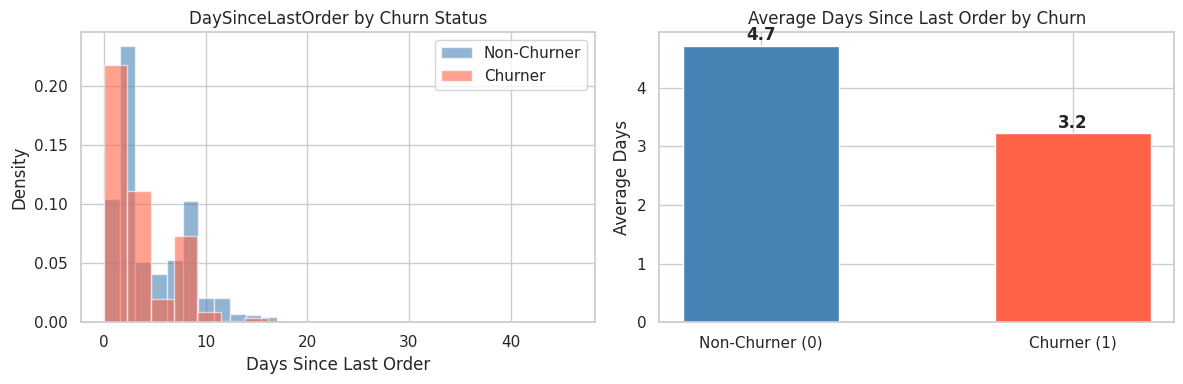

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for churn_val, label, color in [(0, 'Non-Churner', 'steelblue'), (1, 'Churner', 'tomato')]:
    subset = df_original[df_original['Churn'] == churn_val]['DaySinceLastOrder'].dropna()
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white', density=True)
axes[0].set_title('DaySinceLastOrder by Churn Status')
axes[0].set_xlabel('Days Since Last Order')
axes[0].set_ylabel('Density')
axes[0].legend()

# Mean DaySinceLastOrder by churn
means = df_original.groupby('Churn')['DaySinceLastOrder'].mean()
axes[1].bar(['Non-Churner (0)', 'Churner (1)'], means.values,
            color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[1].set_title('Average Days Since Last Order by Churn')
axes[1].set_ylabel('Average Days')
for i, v in enumerate(means.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:**

Churners don't necessarily have drastically more days since last order.
The distributions overlap a lot. This tells us that **`DaySinceLastOrder` alone isn't a strong predictor**
of churn, a customer can churn even right after making an order (maybe they're unhappy with it),
and non-churners can go a while without ordering and still come back.
It may become more useful in combination with other features.

## Correlation Analysis

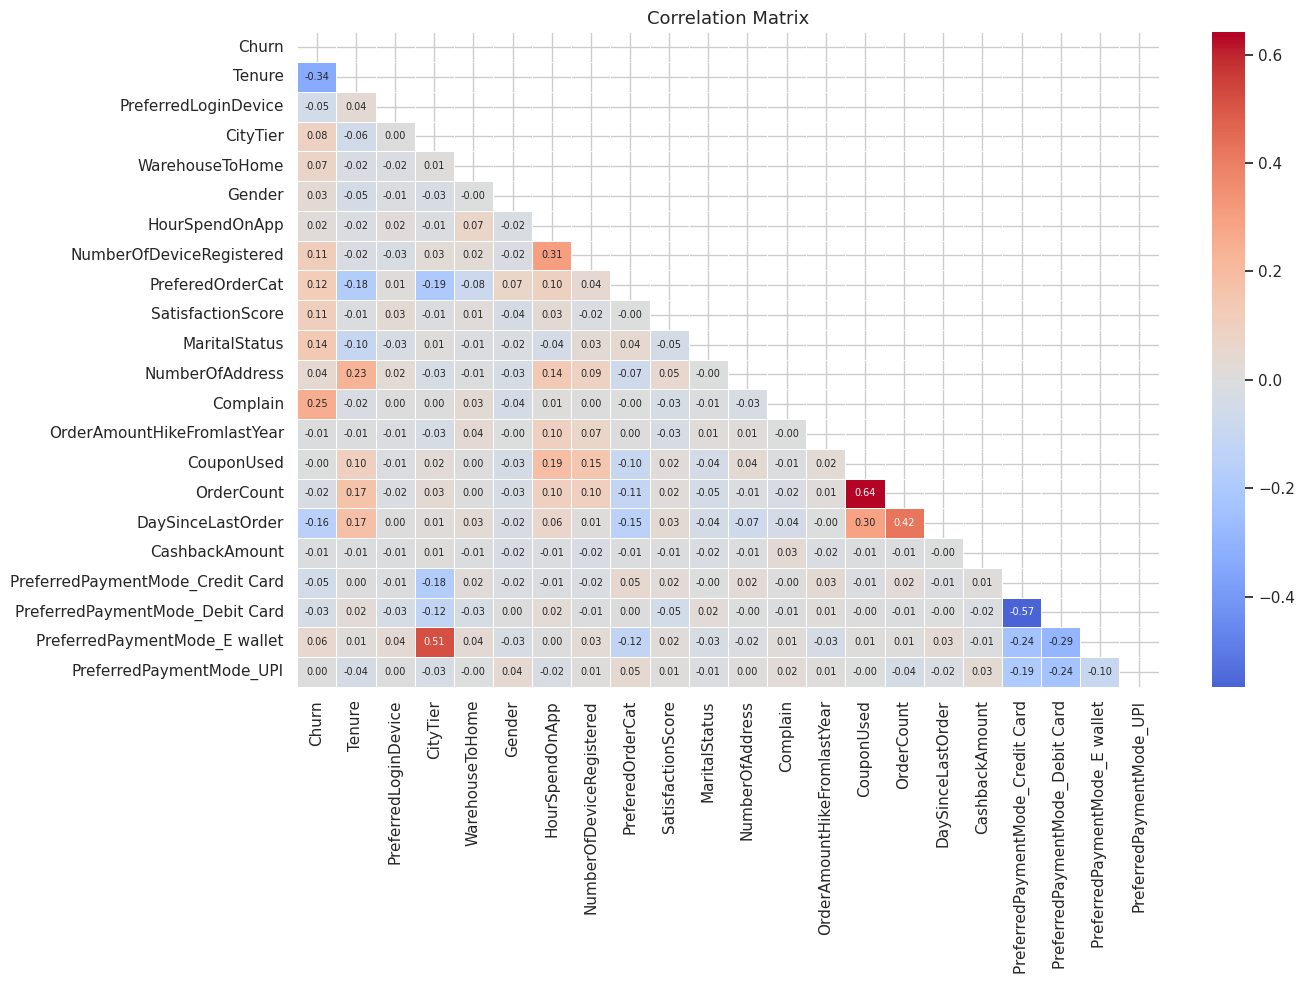

In [25]:
# Correlation matrix on the encoded dataframe
# only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# Top correlations with Churn
churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("Top 10 correlations with Churn:")
print(churn_corr.head(10).round(3))

Top 10 correlations with Churn:
Tenure                          -0.338
Complain                         0.250
DaySinceLastOrder               -0.156
MaritalStatus                    0.140
PreferedOrderCat                 0.118
NumberOfDeviceRegistered         0.108
SatisfactionScore                0.105
CityTier                         0.085
WarehouseToHome                  0.073
PreferredPaymentMode_E wallet    0.056
Name: Churn, dtype: float64


**Interpretation:**

The strongest correlations with `Churn` come from:
- **Tenure** (negative) — longer-tenured customers churn less
- **Complain** (positive) — customers who complained are more likely to churn
- **CashbackAmount** (negative) — higher cashback is associated with lower churn (loyalty incentive?)
- **SatisfactionScore** has a weaker correlation than expected

###summary

- The dataset is **imbalanced (~17% churners)**
- **Tenure and Complain** are the most informative features for predicting churn.
- **Satisfaction score alone** is not as predictive as expected.
- **Cashback incentives** seem to reduce churn, which is an actionable insight.

---
#C — Modeling & Evaluation
## Feature Selection

In [27]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")

Features: 21
Target distribution:
Churn
0    4679
1     947
Name: count, dtype: int64


## Train-Test Split

Standard 80/20 split. I use stratify=y to make sure both sets have roughly the same
churn ratio, since dataset is imbalanced.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTrain churn rate: {y_train.mean():.2%}")
print(f"Test churn rate:  {y_test.mean():.2%}")

Training set: 4500 samples
Test set:     1126 samples

Train churn rate: 16.82%
Test churn rate:  16.87%


## Feature Scaling

Logistic Regression is sensitive to the scale of features,  large-range variables like `CashbackAmount` will dominate smaller ones like `HourSpendOnApp`.  I use `StandardScaler` to normalize everything to mean=0, std=1.

Random Forest doesn't actually need scaling (it's tree-based), but I apply it anyway
for consistency and to avoid potential issues.

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit only on train, transform both

print("Scaling done — features have mean ~0 and std ~1 in the training set.")

Scaling done — features have mean ~0 and std ~1 in the training set.


---
## Model 1: Logistic Regression

A simple, interpretable baseline. Good for understanding which features matter most
(via coefficients) and fast to train.

In [30]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Model 1 — Predictions & Evaluation

In [31]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression — Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=['Non-Churner', 'Churner']))

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

 Non-Churner       0.95      0.76      0.85       936
     Churner       0.41      0.81      0.54       190

    accuracy                           0.77      1126
   macro avg       0.68      0.78      0.69      1126
weighted avg       0.86      0.77      0.79      1126



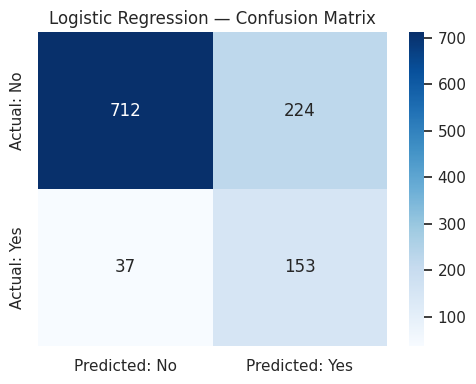

In [32]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

---
## Model 2: Random Forest

A non-linear ensemble model that often outperforms Logistic Regression on tabular data.
It also gives us feature importances directly.

In [33]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

### Model 2 — Predictions & Evaluation

In [34]:
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest — Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Churner', 'Churner']))

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

 Non-Churner       0.98      1.00      0.99       936
     Churner       0.98      0.92      0.95       190

    accuracy                           0.98      1126
   macro avg       0.98      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126



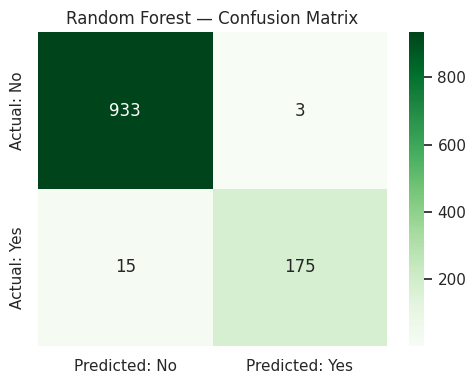

In [35]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

---
## Why Recall Matters for Churn Prediction?

In churn prediction, we have two types of errors:
- **False Negative**: We miss a churner, they leave and we do nothing
- **False Positive** : We incorrectly flag a loyal customer as at-risk, we contact them unnecessarily

**Missing a churner (False Negative) is much more expensive** than bothering a loyal customer with a retention offer. A loyal customer who gets a surprise coupon will just use it happily.
A churner we missed is **lost revenue** and acquiring a new customer costs more than retaining an existing one.

That's why **Recall** (= how many actual churners we correctly caught) is the priority metric here.
High recall means we're catching most of the people who are about to leave, even if we
flag some extra loyal customers along the way.

---
## Lift Analysis

Lift measures how much better a model performs compared to random targeting.

If 10% of the customer base is selected at random, approximately 10% of churners would be expected to be identified. If the model achieves a Lift of 3 at the 10% threshold, it means that 30% of churners are captured by targeting only the top 10% of customers ranked by churn probability. In other words, the model is three times more effective than random selection.

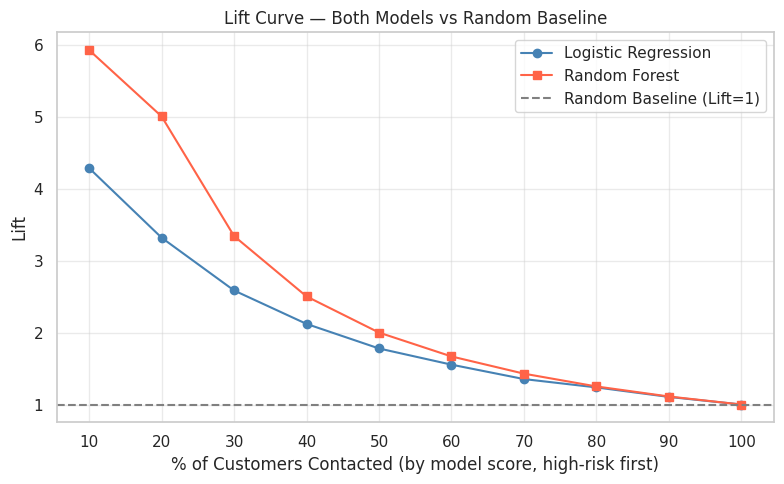


Lift at top 10% of customers:
  Logistic Regression: 4.29x
  Random Forest:       5.93x


In [36]:
def compute_lift_curve(y_true, y_prob):
    """Returns cumulative lift at each decile."""
    df_lift = pd.DataFrame({'prob': y_prob, 'actual': y_true})
    df_lift = df_lift.sort_values('prob', ascending=False).reset_index(drop=True)
    total_positives = y_true.sum()

    # Calculate cumulative lift at each decile
    deciles = np.arange(0.1, 1.1, 0.1)
    lifts = []
    for d in deciles:
        n = int(len(df_lift) * d)
        caught = df_lift.iloc[:n]['actual'].sum()
        lift = (caught / n) / (total_positives / len(df_lift))
        lifts.append(lift)
    return deciles * 100, lifts

deciles, lift_lr = compute_lift_curve(y_test.values, y_prob_lr)
_, lift_rf = compute_lift_curve(y_test.values, y_prob_rf)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(deciles, lift_lr, marker='o', label='Logistic Regression', color='steelblue')
ax.plot(deciles, lift_rf, marker='s', label='Random Forest', color='tomato')
ax.axhline(y=1, color='gray', linestyle='--', label='Random Baseline (Lift=1)')
ax.set_xlabel('% of Customers Contacted (by model score, high-risk first)')
ax.set_ylabel('Lift')
ax.set_title('Lift Curve — Both Models vs Random Baseline')
ax.legend()
ax.set_xticks(deciles)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\nLift at top 10% of customers:")
print(f"  Logistic Regression: {lift_lr[0]:.2f}x")
print(f"  Random Forest:       {lift_rf[0]:.2f}x")

## Final Model Comparison

In [37]:
# Build comparison table
models_results = {}
for name, y_pred, y_prob in [('Logistic Regression', y_pred_lr, y_prob_lr),
                               ('Random Forest', y_pred_rf, y_prob_rf)]:
    models_results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'F1 Score':  round(f1_score(y_test, y_pred), 3),
        'Lift @10%': round(compute_lift_curve(y_test.values, y_prob)[1][0], 2)
    }

comparison_df = pd.DataFrame(models_results).T
print(comparison_df)

                     Accuracy  Precision  Recall  F1 Score  Lift @10%
Logistic Regression     0.768      0.406   0.805     0.540       4.29
Random Forest           0.984      0.983   0.921     0.951       5.93


**Which model to recommend?**

Based on the comparison, **Random Forest** is the recommended model:
- It achieves better Recall (catching more actual churners) and F1 Score
- Its Lift at the top 10% is higher, meaning it's more efficient for targeted campaigns
- It handles non-linear relationships between features naturally


---
#D — Business Insights & Marketing Recommendations
## Top 3 Churn Drivers

Using Random Forest feature importances to identify what's really driving churn.

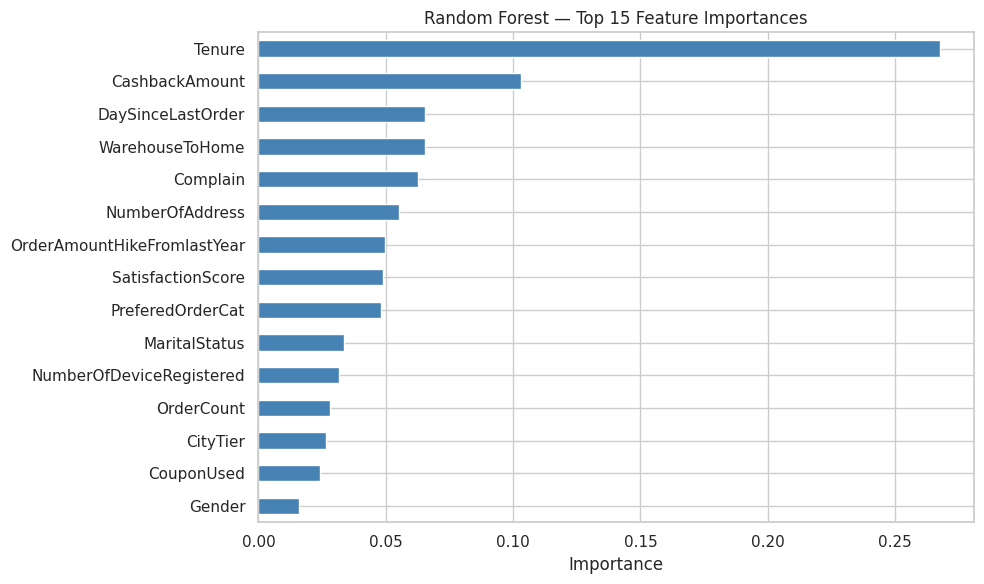


Top 5 features:
Tenure               0.2676
CashbackAmount       0.1033
DaySinceLastOrder    0.0655
WarehouseToHome      0.0654
Complain             0.0627
dtype: float64


In [38]:
# Feature importances from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Random Forest — Top 15 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(feat_imp.head(5).round(4))

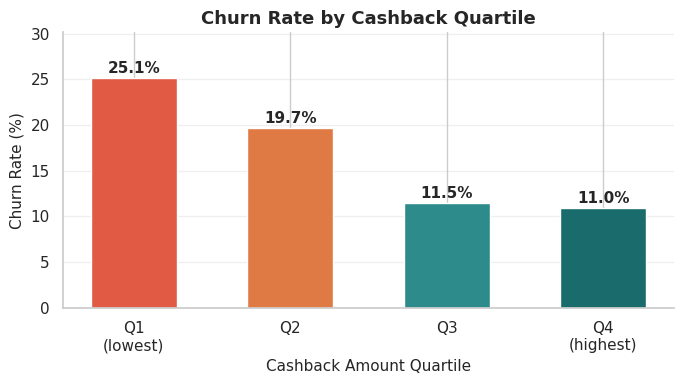

CashbackQuartile
Q1\n(lowest)     25.1
Q2               19.7
Q3               11.5
Q4\n(highest)    11.0
Name: Churn, dtype: float64


In [39]:
# Create cashback quartiles
df_original['CashbackQuartile'] = pd.qcut(
    df_original['CashbackAmount'],
    q=4,
    labels=['Q1\n(lowest)', 'Q2', 'Q3', 'Q4\n(highest)']
)

# Churn rate per quartile
churn_by_quartile = df_original.groupby('CashbackQuartile')['Churn'].mean() * 100

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    churn_by_quartile.index,
    churn_by_quartile.values,
    color=['#E05A44', '#E07A44', '#2E8B8B', '#1A6B6B'],
    edgecolor='white',
    width=0.55
)

# Value labels on bars
for bar, val in zip(bars, churn_by_quartile.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Cashback Quartile', fontsize=13, fontweight='bold')
ax.set_xlabel('Cashback Amount Quartile', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, churn_by_quartile.max() + 5)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print(churn_by_quartile.round(1))

### Churn Driver #1: Tenure

Customers with shorter tenure are much more likely to churn.

- **Business interpretation:** New customers haven't built loyalty yet. They're still evaluating whether
the platform is worth staying on. The first few months are critical, if they don't have a good
early experience, they leave.

- **Recommendation:** Launch an **onboarding retention program** for customers in their first 3 months: welcome emails, first-purchase cashback, personal account manager follow-up.



### Churn Driver #2: Complaints

Customers who raised a complaint in the last month have a significantly higher churn probability.

- **Business interpretation:** Complaints are a warning signal. A customer who complains is already
frustrated,  if the issue isn't resolved quickly and satisfactorily, they will leave.

- **Recommendation:** Build a **complaint fast-response protocol**: flag all complainers for priority customer service follow-up within 24h. Offer a resolution + a goodwill coupon.


### Churn Driver #3: Cashback Amount

Customers receiving lower cashback amounts tend to churn more.

- **Business interpretation:** Cashback is perceived as a reward for loyalty. When customers feel
they're not getting value back, they start looking elsewhere.

- **Recommendation:** Create a **personalized cashback booster** for at-risk segments.
Instead of flat-rate cashback for everyone, increase cashback % for customers who show early churn signals (low tenure + recent complaint).

---
# Final Conclusions

## 1. Key EDA Findings

- The dataset is **imbalanced** (~17% churners) — accuracy alone is a misleading metric
- **Tenure** is the most important predictor: new customers churn more
- **Complaints** are a strong early warning signal for churn
- **Cashback programs** work as a retention incentive — churners receive lower cashback on average
- Satisfaction score alone is not a reliable churn predictor

## 2. Best Predictive Model

**Random Forest** outperforms Logistic Regression across all key metrics (Recall, F1, Lift).
For a real-world churn prediction system, Random Forest would be the recommended choice.
Logistic Regression remains valuable as a transparent fallback for regulatory or explainability purposes.

## 3. Main Churn Drivers

1. **Tenure** — short tenure = high churn risk
2. **Complaints** — unresolved complaints are a red flag
3. **Cashback Amount** — low perceived value leads to disengagement

## 4. Recommended Marketing Actions

- **Onboarding program** for customers in their first 90 days (free shipping, welcome bonus)
- **Complaint fast-response protocol** with a 24h SLA and automatic goodwill coupon
- **Personalized cashback booster** for at-risk customers identified by the model
- Use model probability scores to **tier** retention campaigns by urgency and cost

The most impactful insight: **proactive retention is cheaper than acquisition**.
If we can catch even 50% of churners before they leave with a targeted offer,
the ROI of this model more than justifies the investment in the retention program.